In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../benchmark_runs/60054709/cpu_gpu_benchmark.csv")
df

,size,rep,dimension,graph_seed,embed_seed,beta,backend,backend_reported,mode,build_dir,...,nb_edges_reported,graph_generation_wall_ms,wall_time_ms,total_time_ms,initialization_ms,parameter_inference_ms,initial_positions_ms,refining_positions_ms,adjusting_kappas_ms,io_ms
0,1000,0,1,1013345,1013345,2.0,cpu,cpu,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,4840,80.155407,2.763063e+04,2.761956e+04,12.122755,974.494373,61.556865,2.652388e+04,2.741055e+01,20.084415
1,1000,0,1,1013345,1013345,2.0,gpu,cuda,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,4840,80.155407,3.085972e+03,2.916402e+03,1066.772204,975.687586,55.004945,7.941412e+02,5.919653e+00,18.858602
2,2000,0,1,1014345,1014345,2.0,cpu,cpu,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,10212,253.172533,1.167783e+05,1.167592e+05,41.586459,1402.698450,194.571930,1.148829e+05,1.867796e+02,50.665063
3,2000,0,1,1014345,1014345,2.0,gpu,cuda,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,10212,253.172533,5.744678e+03,5.572917e+03,1099.346610,1400.741742,151.916568,2.883413e+03,2.029560e+01,17.182083
4,5000,0,1,1017345,1017345,2.0,cpu,cpu,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,24332,1217.189641,7.991997e+05,7.991816e+05,99.921594,2080.656130,698.449593,7.954510e+05,8.019112e+02,49.646779
5,5000,0,1,1017345,1017345,2.0,gpu,cuda,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,24332,1217.189641,2.139035e+04,2.119537e+04,1204.238059,2080.424642,566.536282,1.727656e+04,3.449497e+01,33.093413
6,10000,0,1,1022345,1022345,2.0,cpu,cpu,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,49108,5847.099114,3.439453e+06,3.439422e+06,351.911626,2736.509303,1885.175624,3.430578e+06,3.797998e+03,72.759144
7,10000,0,1,1022345,1022345,2.0,gpu,cuda,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,49108,5847.099114,7.455015e+04,7.435143e+04,1460.876409,2741.162929,1618.819880,6.837040e+04,8.114835e+01,79.000315
8,20000,0,1,1032345,1032345,2.0,cpu,cpu,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,101628,18249.294846,1.482368e+07,1.482362e+07,1067.482213,4089.680912,7911.544651,1.473674e+07,7.371560e+04,91.596686
9,20000,0,1,1032345,1032345,2.0,gpu,cuda,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,101628,18249.294846,2.870646e+05,2.868374e+05,2199.564555,4096.843956,5439.995153,2.742111e+05,7.843701e+02,105.435389


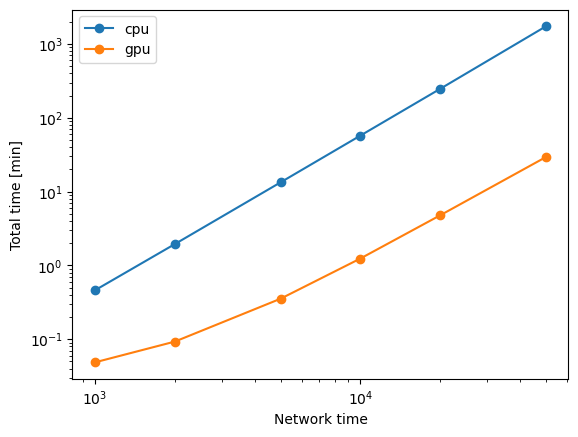

In [34]:
for name, group in df.groupby("backend"):
    plt.plot(group['size'], group['total_time_ms'] / 1000 / 60, 'o-', label=name)
plt.legend()
plt.xlabel('Network time')
plt.ylabel('Total time [min]')
plt.xscale("log")
plt.yscale("log")

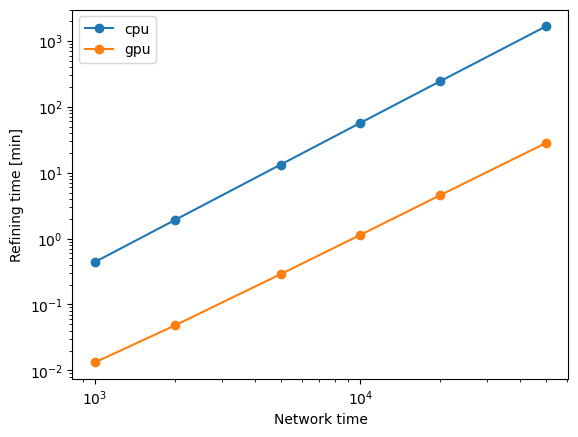

In [35]:
for name, group in df.groupby("backend"):
    plt.plot(group['size'], group['refining_positions_ms'] / 1000 / 60, 'o-', label=name)
plt.legend()
plt.xlabel('Network time')
plt.ylabel('Refining time [min]')
plt.xscale("log")
plt.yscale("log")

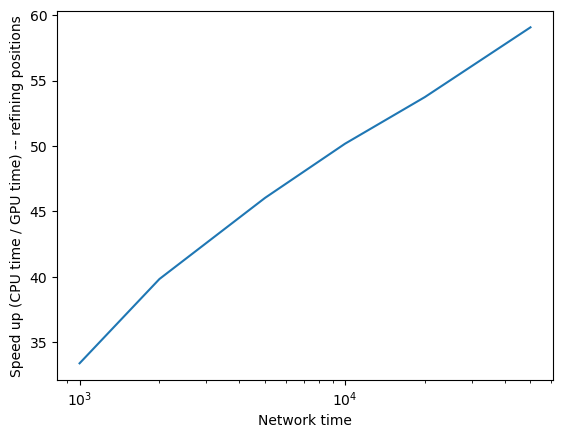

In [36]:
speed_up = []
sizes = []

for name, group in df.groupby("size"):
    sizes.append(name)
    cpu_time = group[group['backend'] == 'cpu']['refining_positions_ms'].values[0]
    gpu_time = group[group['backend'] == 'gpu']['refining_positions_ms'].values[0]
    
    speed_up.append(cpu_time / gpu_time)

plt.plot(sizes, speed_up)
plt.xlabel('Network time')
plt.ylabel('Speed up (CPU time / GPU time) -- refining positions')
plt.xscale("log")
plt.show()

In [37]:
def fit_loglog(sub):
    x = np.log10(sub["size"].to_numpy(dtype=float))
    y = np.log10(sub["total_time_ms"].to_numpy(dtype=float))
    alpha, beta = np.polyfit(x, y, 1)
    yhat = alpha*x + beta
    r2 = 1 - ((y - yhat)**2).sum() / ((y - y.mean())**2).sum() if len(y) > 1 else np.nan
    c = 10**beta
    return alpha, beta, c, r2

for backend, sub in df.groupby("backend"):
    alpha, beta, c, r2 = fit_loglog(sub)
    print(backend, alpha, beta, c, r2)

cpu 2.1044278468868454 -1.877753845982256 0.013250923722542888 0.9999884065726607
gpu 1.6610251938803742 -1.6819536457155193 0.020799186747200063 0.9871357838019316


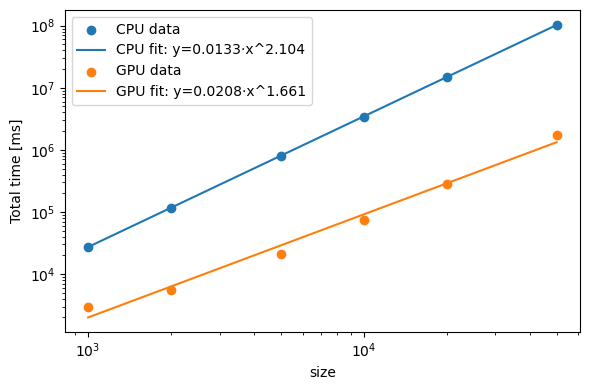

In [38]:
fits = {b: fit_loglog(sub) for b, sub in df.groupby("backend")}

# Plot
fig, ax = plt.subplots(figsize=(6, 4))

for backend, sub in df.groupby("backend"):
    ax.scatter(sub["size"], sub["total_time_ms"], label=f"{backend.upper()} data")

    alpha, beta, c, r2 = fits[backend]
    # Use range of x for that backend
    x_min, x_max = sub["size"].min(), sub["size"].max()
    xs = np.logspace(np.log10(x_min), np.log10(x_max), 200)
    ys = c * xs**alpha
    ax.plot(xs, ys, label=f"{backend.upper()} fit: y={c:.3g}·x^{alpha:.3f}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("size")
ax.set_ylabel("Total time [ms]")
ax.legend()
plt.tight_layout()
plt.show()


In [68]:
def fit_loglog(sub):
    x = np.log10(sub["size"].to_numpy(dtype=float))
    y = np.log10(sub["total_time_ms"].to_numpy(dtype=float))
    alpha, beta = np.polyfit(x, y, 1)
    c = 10**beta
    return alpha, c, beta
    
fits = {}
for backend, sub in df.groupby("backend"):
    alpha, c, beta = fit_loglog(sub)
    fits[backend] = {"alpha": alpha, "c": c, "beta": beta}

sizes = np.array([20000, 100_000, 500_000, 1_000_000, 1_500_000, 2_000_000], dtype=float)

rows = []
for n in sizes:
    row = {"size": int(n)}
    for backend in ["cpu", "gpu"]:
        alpha = fits[backend]["alpha"]
        c = fits[backend]["c"]
        y_ms = c * (n ** alpha)
        row[f"{backend}_pred_ms"] = y_ms
        row[f"{backend}_pred_s"] = y_ms / 1000.0
        row[f"{backend}_pred_min"] = y_ms / (1000.0 * 60.0)
        row[f"{backend}_pred_h"] = y_ms / (1000.0 * 3600.0)
    rows.append(row)

pred = pd.DataFrame(rows)

pred

,size,cpu_pred_ms,cpu_pred_s,cpu_pred_min,cpu_pred_h,gpu_pred_ms,gpu_pred_s,gpu_pred_min,gpu_pred_h
0,20000,1.490917e+07,1.490917e+04,2.484862e+02,4.141436,2.898448e+05,289.844816,4.830747,0.080512
1,100000,4.409460e+08,4.409460e+05,7.349100e+03,122.484995,4.199256e+06,4199.255732,69.987596,1.166460
2,500000,1.304119e+10,1.304119e+07,2.173532e+05,3622.553674,6.083859e+07,60838.585854,1013.976431,16.899607
3,1000000,5.608068e+10,5.608068e+07,9.346779e+05,15577.965388,1.923967e+08,192396.655188,3206.610920,53.443515
4,1500000,1.316390e+11,1.316390e+08,2.193983e+06,36566.389730,3.773024e+08,377302.371806,6288.372863,104.806214
5,2000000,2.411621e+11,2.411621e+08,4.019369e+06,66989.485177,6.084374e+08,608437.431742,10140.623862,169.010398


In [55]:
coords_cpu = pd.read_csv("../benchmark_runs/60054709/artifacts/d1_n50000_seed1062345/embed_cpu_rep00.coords.csv")
coords_gpu = pd.read_csv("../benchmark_runs/60054709/artifacts/d1_n50000_seed1062345/embed_gpu_rep00.coords.csv")
coords_original = pd.read_csv("../benchmark_runs/60054709/artifacts/d1_n50000_seed1062345/synthetic_sd.truth.csv")

# coords_cpu = pd.read_csv("../benchmark_runs/60054709/artifacts/d1_n1000_seed1013345/embed_cpu_rep00.coords.csv")
# coords_gpu = pd.read_csv("../benchmark_runs/60054709/artifacts/d1_n1000_seed1013345/embed_gpu_rep00.coords.csv")
# coords_original = pd.read_csv("../benchmark_runs/60054709/artifacts/d1_n1000_seed1013345/synthetic_sd.truth.csv")

In [56]:
coords_cpu.columns = ['node_id', 'r_cpu', 'kappa_cpu', 'theta_cpu']
coords_gpu.columns = ['node_id', 'r_gpu', 'kappa_gpu', 'theta_gpu']

coords = coords_cpu.merge(coords_original, on='node_id')
coords = coords.merge(coords_gpu, on='node_id')
coords.head()

,node_id,r_cpu,kappa_cpu,theta_cpu,r,kappa,theta_0,r_gpu,kappa_gpu,theta_gpu
0,v0,48.8907,3.68318,5.83234,25.1293,4.21498,0.913700,48.8907,3.68318,5.83234
1,v1,47.8265,6.27067,4.58908,24.9404,4.63244,2.196290,47.8265,6.27067,4.58908
2,v10,48.1444,5.34895,1.82622,24.0709,7.15523,4.930180,48.1444,5.34895,1.82622
3,v100,47.4386,7.61281,6.21309,23.3395,10.31460,0.527381,47.4386,7.61281,6.21309
4,v1000,48.2932,4.96554,1.48811,25.0306,4.42821,5.269930,48.2932,4.96554,1.48811


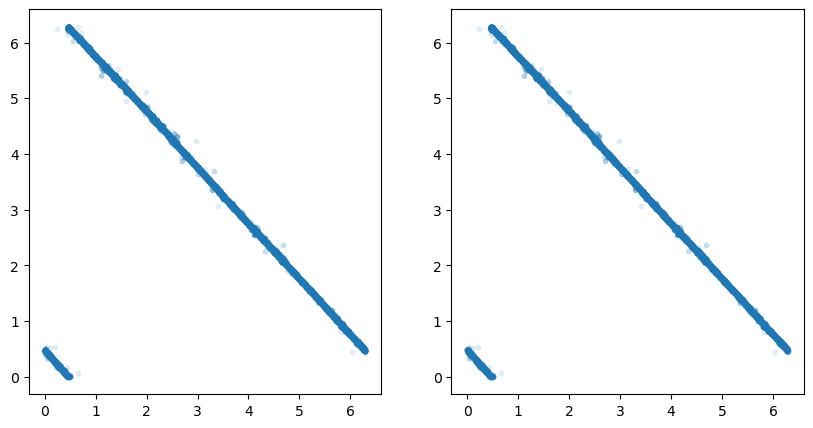

In [62]:
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
plt.scatter(coords['theta_0'], coords['theta_cpu'], marker='.', alpha=0.1)
plt.subplot(1, 2, 2)
plt.scatter(coords['theta_0'], coords['theta_gpu'], marker='.', alpha=0.1)

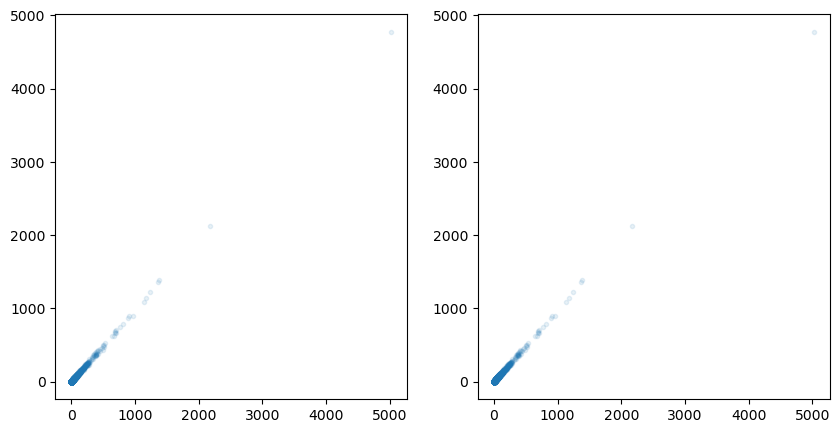

In [64]:
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
plt.scatter(coords['kappa'], coords['kappa_cpu'], marker='.', alpha=0.1)
plt.subplot(1, 2, 2)
plt.scatter(coords['kappa'], coords['kappa_gpu'], marker='.', alpha=0.1)

In [69]:

new_coords_gpu = pd.read_csv("../benchmark_runs/60347914/artifacts/d1_n20000_seed1032345/embed_gpu_rep00.coords.csv")
new_coords_original = pd.read_csv("../benchmark_runs/60347914/artifacts/d1_n20000_seed1032345/synthetic_sd.truth.csv")
new_coords_gpu.columns = ['node_id', 'r_gpu', 'kappa_gpu', 'theta_gpu']

new_coords = new_coords_gpu.merge(new_coords_original, on='node_id')
new_coords

,node_id,r_gpu,kappa_gpu,theta_gpu,r,kappa,theta_0
0,v0,36.1199,14.47590,1.310220,19.7590,17.75040,0.282876
1,v1,39.1103,3.24558,0.701991,21.9427,5.95716,0.915240
2,v10,36.5432,11.71460,6.245920,20.5267,12.09220,1.600640
3,v100,40.3916,1.71023,5.075000,22.6577,4.16654,2.773980
4,v1000,35.4521,20.21390,2.039070,19.6458,18.78460,5.814700
...,...,...,...,...,...,...,...
19981,v9995,31.9757,114.95900,1.148010,15.9667,118.22500,0.443497
19982,v9996,40.0853,1.99329,2.712290,23.8476,2.29820,5.139200
19983,v9997,34.3301,35.42420,4.967470,18.5595,32.33590,2.881240
19984,v9998,38.6812,4.02226,2.156620,21.7703,6.49321,5.697630


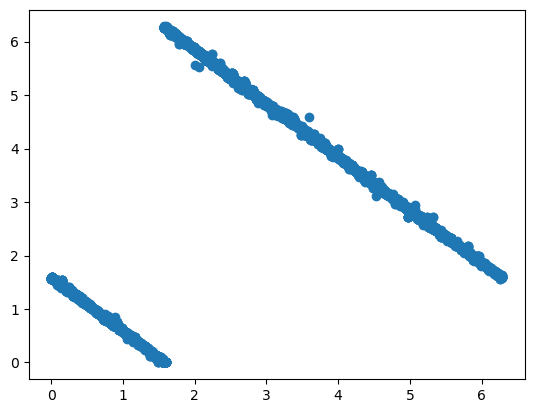

In [70]:
plt.scatter(new_coords['theta_0'], new_coords['theta_gpu'])

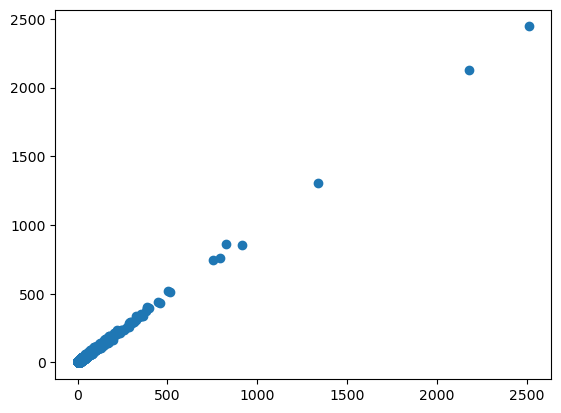

In [72]:
plt.scatter(new_coords['kappa'], new_coords['kappa_gpu'])

In [73]:
df_gpu = pd.read_csv("../benchmark_runs/60347914/cpu_gpu_benchmark.csv")
df_gpu

,size,rep,dimension,graph_seed,embed_seed,beta,backend,backend_reported,mode,build_dir,...,nb_edges_reported,graph_generation_wall_ms,wall_time_ms,total_time_ms,initialization_ms,parameter_inference_ms,initial_positions_ms,refining_positions_ms,adjusting_kappas_ms,io_ms
0,1000,0,1,1013345,1013345,2.0,gpu,cuda,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,4840,89.248842,2285.282360,2124.283172,978.055929,974.333443,55.031398,105.243541,5.932605,5.667416
1,2000,0,1,1014345,1014345,2.0,gpu,cuda,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,10212,254.113897,2614.197171,2440.797043,671.953661,1400.763940,149.540487,189.043937,20.259265,9.214913
2,5000,0,1,1017345,1017345,2.0,gpu,cuda,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,24332,1212.377272,4384.211771,4205.466567,864.781935,2080.572476,565.118702,637.789477,34.620024,22.556973
3,10000,0,1,1022345,1022345,2.0,gpu,cuda,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,49108,5806.843796,7808.836749,7618.351274,1300.161717,2741.959734,1613.533129,1837.510349,81.089428,44.070037
4,20000,0,1,1032345,1032345,2.0,gpu,cuda,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,101628,18277.014117,23290.254382,23075.869295,2080.370206,4090.498244,9209.974299,6806.180359,782.703687,106.112600
5,50000,0,1,1062345,1062345,2.0,gpu,cuda,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,246154,130463.627335,106480.362125,106180.183712,4566.595736,6023.868610,34291.727628,42146.104054,18955.025870,196.828674
6,100000,0,1,1112345,1112345,2.0,gpu,cuda,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,498463,521543.998127,436508.259949,436031.642132,13979.403477,8848.561850,194706.288338,163023.868312,55122.867475,350.615591


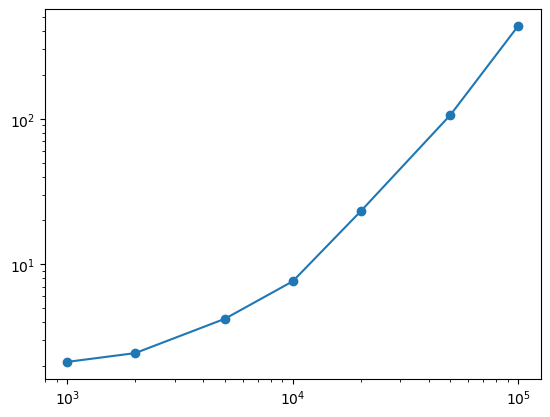

In [77]:
plt.plot(df_gpu['size'], df_gpu['total_time_ms']/1000, 'o-')
plt.xscale('log')
plt.yscale('log')

In [79]:
def fit_loglog(sub):
    x = np.log10(sub["size"].to_numpy(dtype=float))
    y = np.log10(sub["total_time_ms"].to_numpy(dtype=float))
    alpha, beta = np.polyfit(x, y, 1)
    c = 10**beta
    return alpha, c, beta
    
fits = {}
for backend, sub in df_gpu.groupby("backend"):
    alpha, c, beta = fit_loglog(sub)
    fits[backend] = {"alpha": alpha, "c": c, "beta": beta}

sizes = np.array([20000, 100_000, 500_000, 1_000_000, 1_500_000, 2_000_000], dtype=float)

rows = []
for n in sizes:
    row = {"size": int(n)}
    for backend in ["gpu"]:
        alpha = fits[backend]["alpha"]
        c = fits[backend]["c"]
        y_ms = c * (n ** alpha)
        row[f"{backend}_pred_ms"] = y_ms
        row[f"{backend}_pred_s"] = y_ms / 1000.0
        row[f"{backend}_pred_min"] = y_ms / (1000.0 * 60.0)
        row[f"{backend}_pred_h"] = y_ms / (1000.0 * 3600.0)
    rows.append(row)

pred = pd.DataFrame(rows)

pred

,size,gpu_pred_ms,gpu_pred_s,gpu_pred_min,gpu_pred_h
0,20000,3.382290e+04,33.822901,0.563715,0.009395
1,100000,2.206257e+05,220.625678,3.677095,0.061285
2,500000,1.439134e+06,1439.134084,23.985568,0.399759
3,1000000,3.227481e+06,3227.481154,53.791353,0.896523
4,1500000,5.176624e+06,5176.623725,86.277062,1.437951
5,2000000,7.238127e+06,7238.126534,120.635442,2.010591
